In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras import datasets, layers, models
from sklearn.metrics import classification_report

In [2]:
(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print('Training images:',x_test.shape)
print('Training Labels:',y_test.shape)

print('Testing images:',x_train.shape)
print('Testing images:',y_train.shape)


Training images: (10000, 28, 28)
Training Labels: (10000,)
Testing images: (60000, 28, 28)
Testing images: (60000,)


In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [5]:
print(x_train.shape)
print(x_train[0].shape)
print(y_train[0])
print(x_train[0])

(60000, 28, 28)
(28, 28)
9
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.    

In [6]:
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

In [7]:
class_names = [

"T-shirt",

"Trouser",

"Pullover",

"Dress",

"Coat",

"Sandal",

"Shirt",

"Sneaker",

"Bag",

"Boot"
]

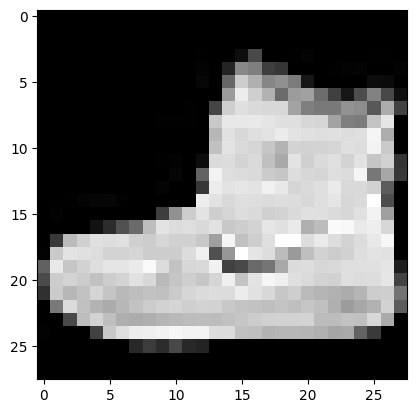

In [9]:
plt.imshow(x_train[0].reshape(28,28),cmap='grey')

In [10]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
from sklearn import metrics
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [12]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test,y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.8600 - loss: 0.3980 - val_accuracy: 0.8841 - val_loss: 0.3201
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9014 - loss: 0.2715 - val_accuracy: 0.8926 - val_loss: 0.3041
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9155 - loss: 0.2304 - val_accuracy: 0.8989 - val_loss: 0.2719
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9257 - loss: 0.2016 - val_accuracy: 0.9128 - val_loss: 0.2457
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9347 - loss: 0.1782 - val_accuracy: 0.9139 - val_loss: 0.2517
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9404 - loss: 0.1580 - val_accuracy: 0.9146 - val_loss: 0.2494
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.9481 - loss: 0.1376 - val_accuracy: 0.9142 - val_loss: 0.2604
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.9551 -

In [13]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9135 - loss: 0.2992


[0.29920947551727295, 0.9135000109672546]

In [14]:
predictions=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [15]:
predicted=np.argmax(predictions,axis=1)


In [16]:
predictions = model.predict(x_test)

predicted = np.argmax(predictions, axis=1)

print(predicted[:10])
print(y_test[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
[9 2 1 1 6 1 4 6 5 7]
[9 2 1 1 6 1 4 6 5 7]


In [18]:
predictions = model.predict(x_test)

predicted = np.argmax(predictions, axis=1)

print(predicted[:10])
print(y_test[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
[9 2 1 1 6 1 4 6 5 7]
[9 2 1 1 6 1 4 6 5 7]


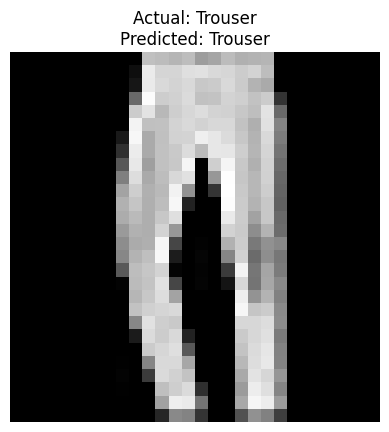

In [19]:
plt.imshow(x_test[5].reshape(28,28), cmap="gray")

plt.title(
    f"Actual: {class_names[y_test[5]]}\nPredicted: {class_names[predicted[5]]}"
)

plt.axis("off")
plt.show()